In [27]:
import pandas as pd

In [28]:
# Import the data from 01_eda.ipynb
%store -r df_store

In [ ]:
# Split the data - Train/Test (Time-based)

# Sort properly
df_store = df_store.sort_values(["store_nbr", "date"])

# Choose split date (last 3 months as test)
split_date = df_store["date"].max() - pd.DateOffset(months=3)

train = df_store[df_store["date"] <= split_date]
test = df_store[df_store["date"] > split_date]

print(train.shape, test.shape)

Shape after feature creation: (89316, 13)
Available columns: ['date', 'store_nbr', 'sales', 'onpromotion', 'year', 'month', 'dayofweek', 'weekofyear', 'lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30']
Train shape: (84348, 13) Test shape: (4968, 13)


In [35]:
# Define Features and Target

features = [
    "onpromotion",
    "month",
    "dayofweek",
    "weekofyear",
    "year",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_7",
    "rolling_30"
]

target = "sales"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Features shape:", X_train.shape)
print("Target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)


Features shape: (84348, 10)
Target shape: (84348,)
Test features shape: (4968, 10)
Test target shape: (4968,)


In [36]:
# Evaluate Models

from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print("RMSE:", rmse)
    return rmse


In [ ]:
# Model-1:- Baseline = Predict yesterday’s sales (lag_1)
baseline_preds = X_test["lag_1"]
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 5348.026770939768


In [42]:
# Model-2: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_rmse = evaluate(rf, X_test, y_test)


RMSE: 2484.7829903430775


In [43]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [52]:
# Model-3: XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_rmse = evaluate(xgb, X_test, y_test)

RMSE: 2119.471811472895


In [45]:
print("Baseline RMSE:", baseline_rmse)
print("Random Forest RMSE:", rf_rmse)
print("XGBoost RMSE:", xgb_rmse)

Baseline RMSE: 5348.026770939768
Random Forest RMSE: 2484.7829903430775
XGBoost RMSE: 2278.188746293116


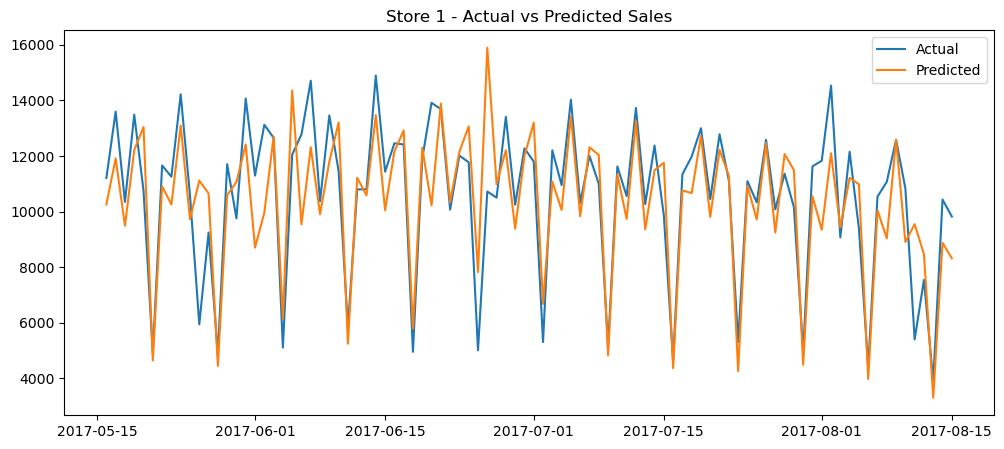

In [ ]:
# Visualize predictions for one store

import matplotlib.pyplot as plt

test_sample = test[test["store_nbr"] == 1]

X_sample = test_sample[features]
y_sample = test_sample["sales"]

preds = xgb.predict(X_sample)

plt.figure(figsize=(12,5))
plt.plot(test_sample["date"], y_sample, label="Actual")
plt.plot(test_sample["date"], preds, label="Predicted")
plt.legend()
plt.title("Store 1 - Actual vs Predicted Sales")
plt.show()


       feature  importance
8    rolling_7    0.545677
6        lag_7    0.258230
9   rolling_30    0.073093
2    dayofweek    0.043411
5        lag_1    0.035881
3   weekofyear    0.011934
1        month    0.009585
4         year    0.009493
0  onpromotion    0.007258
7       lag_30    0.005438


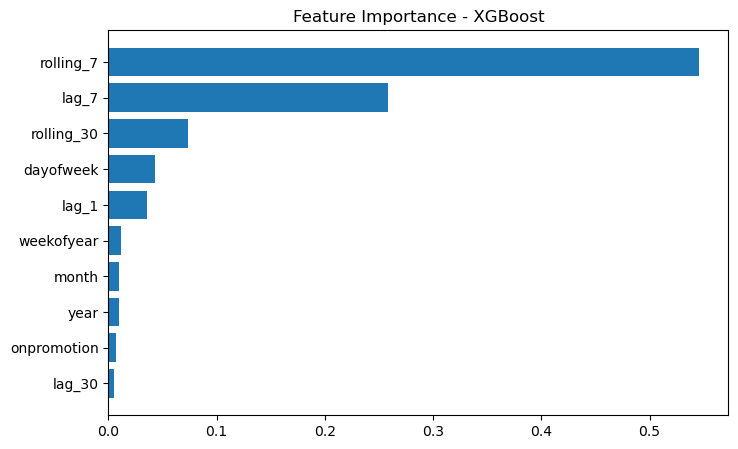

In [47]:
# Model-4: Feature Importance
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(8,5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()


In [48]:
# Feature Importance
feat_imp = pd.DataFrame({
    "feature": features,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_imp)


       feature  importance
8    rolling_7    0.545677
6        lag_7    0.258230
9   rolling_30    0.073093
2    dayofweek    0.043411
5        lag_1    0.035881
3   weekofyear    0.011934
1        month    0.009585
4         year    0.009493
0  onpromotion    0.007258
7       lag_30    0.005438


In [49]:
# Convert store_nbr to categorical
df_store["store_nbr"] = df_store["store_nbr"].astype("category")

# Add store_nbr to features
features = features + ["store_nbr"]


In [50]:
X_train = pd.get_dummies(train[features], drop_first=True)
X_test = pd.get_dummies(test[features], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


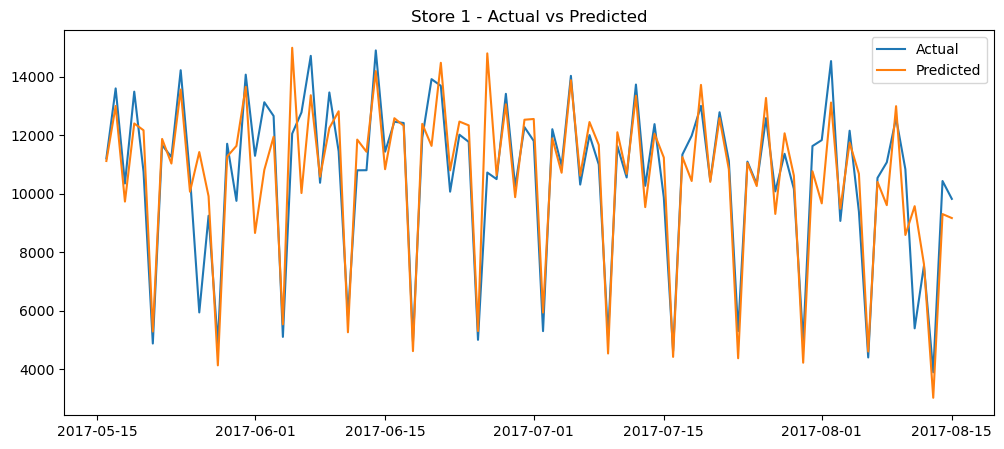

In [53]:
store_1_test = test[test["store_nbr"] == 1]

X_store = pd.get_dummies(store_1_test[features], drop_first=True)
X_store = X_store.reindex(columns=X_train.columns, fill_value=0)

preds = xgb.predict(X_store)

plt.figure(figsize=(12,5))
plt.plot(store_1_test["date"], store_1_test["sales"], label="Actual")
plt.plot(store_1_test["date"], preds, label="Predicted")
plt.legend()
plt.title("Store 1 - Actual vs Predicted")
plt.show()


In [54]:
# Feature Importance
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_imp)


        feature  importance
8     rolling_7    0.559517
6         lag_7    0.223433
9    rolling_30    0.087523
2     dayofweek    0.040624
5         lag_1    0.039144
3    weekofyear    0.011179
10    store_nbr    0.008512
1         month    0.008452
4          year    0.008364
0   onpromotion    0.007183
7        lag_30    0.006070


In [55]:
# Quantify the forecast accuracy
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, xgb.predict(X_test))
print("MAPE:", mape)


MAPE: 0.09755425367893174


In [56]:
# Business Framing
avg_sales = y_test.mean()
error_percentage = xgb_rmse / avg_sales * 100

print(f"Forecast error is {error_percentage:.2f}% of average daily sales")


Forecast error is 13.39% of average daily sales


| MAPE     | Interpretation |
| -------- | -------------- |
| >20%     | Weak           |
| 15–20%   | Decent         |
| 10–15%   | Good           |
| **<10%** | 🔥 Very Strong |
| <7%      | Elite level    |
